# Day 15(M4 Day02) 실습 — Hybrid Memory와 체크포인트 저장기(checkpointer)

> **용어 기준:** 그래프의 상태(state)는 현재 실행 데이터를, 체크포인트(checkpoint)는 저장 시점의 실행 상태를 말한다. 체크포인트 저장기(checkpointer)는 저장·복원하는 구현이다. 대화 메모리는 상태 저장 기능을 활용할 수 있지만 상태와 동의어는 아니다.


**목표**: 지식 검색(장기 기억)과 대화 기억(단기 기억)을 하나의 그래프로 연결하고, 체크포인트 저장기로 대화를 저장·복원·격리한다.
**구성**: Part 1 RAG+생성 그래프 연결(+thread_id 누락·빈 대화 오류 2종) → Part 2 체크포인트 저장·복원·격리(+온라인 쇼핑몰 고객 지원 도메인 반복) → Part 3 기억+검색 에이전트(+M1 Day04 방어를 더한 면접 코치의 Hybrid Memory 통합)

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`·`DATABASE_URL`을 확인한다. 새 패키지는 없다(체크포인트 저장기는 langgraph 동봉).

## 0. 환경 준비

In [1]:
import os
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_postgres import PGVector
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
CONN = os.getenv("DATABASE_URL").replace("postgresql://", "postgresql+psycopg://")

from sqlalchemy import create_engine
# PGVector에 주소 문자열(CONN)을 넘기면 부를 때마다 연결 풀을 새로 만들고, 만든 연결을 계속 붙잡고 있다.
# Supabase Session pooler는 프로젝트당 동시 연결을 15개까지만 받는다.
# 엔진(연결 풀) 하나를 만들어 모든 PGVector가 같이 쓴다.
engine = create_engine(CONN, pool_size=2, max_overflow=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("준비 완료")

준비 완료


## Part 1. RAG+생성 그래프 연결 — 기초

완성 코드를 직접 쳐서 지식 검색과 대화 기억을 하나의 그래프로 연결한다.

### 1-1. 지식 저장·리트리버(Retriever) (장기 기억)

회사 규정을 pgvector에 저장하고 리트리버를 만든다.

In [2]:
KNOW = [
    "회사 연차 휴가는 1년에 15일이다.",
    "회사 점심시간은 12시부터 오후 1시까지다.",
    "회사 재택근무는 주 2일까지 가능하다.",
]
# TODO: KNOW를 collection_name="company_know"인 PGVector store에 저장하고
#       search_kwargs={"k": 1}인 retriever로 변환하세요
store = PGVector(embeddings=embeddings, 
                 collection_name="company_know", 
                 connection=engine, 
                 use_jsonb=True,
                 pre_delete_collection=True)
store.add_texts(KNOW)
retriever = store.as_retriever(search_kwargs={"k":1}) # 회사지식저장소

print("지식 저장 완료")

지식 저장 완료


### 1-2. State 정의

대화(messages)와 검색된 지식(context)을 담는다.

In [3]:
# TODO: messages(list, add_messages로 누적)와 context(str)를 담는 State(TypedDict)를 정의하세요

class State(TypedDict):
    messages: Annotated[list, add_messages]
    context: str

print("State 정의 완료")

State 정의 완료


### 1-3. retrieve·generate 노드

retrieve는 지식 검색, generate는 지식+대화로 답변한다.

In [4]:
# TODO: 마지막 메시지로 지식을 검색해 context를 돌려주는 retrieve 함수를 만드세요
# def retrieve(s) -> str:
#     # 지식 검색
#     docs = retriever.invoke(s["messages"][-1].content) # 지식 검색 결과
#     return {"context" : "\n".join([doc.page_content for doc in docs])} # 지식검색 결과 반환

def retrieve(s) -> str:
    # 지식 검색
    if not s["messages"]:
        return {"context" :""}
    
    docs = retriever.invoke(s["messages"][-1].content) # 지식 검색 결과
    return {"context" : "\n".join([doc.page_content for doc in docs])} # 지식검색 결과 반환


# TODO: context를 담은 SystemMessage와 대화 기록(messages)으로 llm을 호출해 답을 돌려주는
#       generate 함수를 만드세요

def generate(s) -> str:
    # llm 호출 > 응답 생성
    system_prompt = SystemMessage(
        f"""
        너는 회사 안내 챗봇이다. 아래 지식을 참고해서 친근히 답하라
        지식 : \n{s['context']}
        """
    )
    return {"messages": [llm.invoke([system_prompt] + s["messages"])]} # llm 호출 > 응답 생성


print("노드 작성 완료")

노드 작성 완료


### 1-4. 그래프 연결 + 체크포인트 저장기

START→retrieve→generate→END를 잇고, 체크포인트 저장기로 대화를 저장한다.

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	generate(generate)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	retrieve --> generate;
	generate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



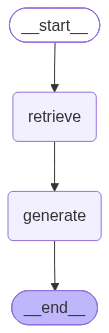

In [5]:
# TODO: retrieve·generate 노드를 add_node로 추가하고, START->retrieve->generate->END로 잇고
#       checkpointer=MemorySaver()로 app을 compile하세요

g = StateGraph(State) # State 딕셔너리를 들고 다니는 그래프 g 생성
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate",END)

app = g.compile(checkpointer=MemorySaver())

print(app.get_graph().draw_mermaid())

app


### 1-5. thread_id로 대화

체크포인트 저장기가 대화를 구분하도록 thread_id를 넘긴다.

In [6]:
# TODO: thread_id를 config로 넘겨 app.invoke를 호출하고 마지막 메시지 내용을 반환하는
#       chat(thread, text) 함수를 만드세요
def chat(thread,text):
    # thread id 설정
    conf = {"configurable" : {"thread_id": thread}}
    # invoke
    return app.invoke({"messages":[HumanMessage(text)]}, conf)["messages"][-1].content

print(chat("userA", "내 이름은 철수야. 연차는 며칠이야?")) # RAG 그래프 호출

안녕하세요, 철수님! 회사의 연차 휴가는 1년에 15일이에요. 필요한 날에 잘 활용하시길 바랄게요! 궁금한 점이 있으면 언제든지 물어보세요.


In [7]:
print(chat("userA", "재택근무가 가능해?")) # RAG 그래프 호출

네, 철수님! 재택근무는 주 2일까지 가능해요. 필요하신 날에 재택근무를 신청하시면 됩니다. 더 궁금한 점이 있으면 언제든지 말씀해 주세요!


In [8]:
print(chat("userA", "점심시간 몇시야?")) # RAG 그래프 호출

점심시간은 12시부터 오후 1시까지예요! 맛있는 점심 드시고 힘내세요! 다른 질문이 있으면 언제든지 물어보세요.


In [9]:
print(chat("userA", "내가 먼저 물어본 내용들을 알려줘")) # RAG 그래프 호출

물론이죠, 철수님! 지금까지 물어보신 내용은 다음과 같아요:

1. 연차는 며칠인지
2. 재택근무가 가능한지
3. 점심시간이 몇 시인지

더 궁금한 점이 있으면 언제든지 말씀해 주세요!


In [10]:
state = app.get_state({"configurable" : {"thread_id" : "userA"}})

print(len(state.values["messages"]))
state

8


StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 철수야. 연차는 며칠이야?', additional_kwargs={}, response_metadata={}, id='136d4a9f-466f-4453-9c62-0dc21e5d9848'), AIMessage(content='안녕하세요, 철수님! 회사의 연차 휴가는 1년에 15일이에요. 필요한 날에 잘 활용하시길 바랄게요! 궁금한 점이 있으면 언제든지 물어보세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 70, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_020b94f7ea', 'id': 'chatcmpl-EVs58Dsv1FExEhE3DLPdiC47StCkH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a10fb3-352d-7ce3-ad51-92656dd400fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens': 50, 'total_tokens

### 1-6. 오류 대응 ① — thread_id 없이 invoke하면?

체크포인트 저장기가 붙은 그래프에 `config` 없이 `invoke`하면 어떻게 되는지 확인한다.

In [11]:
try:
    # TODO: config(thread_id) 없이 app.invoke({"messages": [HumanMessage("안녕")]})을 실행해보세요


    print("실행 성공(예상 밖):", r["messages"][-1].content)
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", e)

오류 발생: NameError - name 'r' is not defined


> **주의:** 결과는 실제 실행에서 직접 확인한다. 체크포인트 저장기는 State를 어느 `thread_id`에 저장할지 알아야 하므로, `config`의 `configurable.thread_id`가 없으면 그래프 실행 자체가 거부된다.

### 1-7. 오류 대응 ② — 대화 기록이 비어 있으면?

`messages`를 빈 리스트로 두고 실행하면 `retrieve`가 어떻게 되는지 확인한다.

In [12]:
try:
    # TODO: messages를 빈 리스트로 두고 app.invoke를 thread_id="empty_test"로 실행해보세요
    res1 = app.invoke({"messages": []}, {"configurable":{"thread_id" : "empty_test"}})  # chat X


    print("실행 성공(예상 밖):", res1)
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", e)

실행 성공(예상 밖): {'messages': [AIMessage(content='안녕하세요! 회사에 대해 궁금한 점이 있으신가요? 언제든지 물어보세요! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 37, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d5b340d02', 'id': 'chatcmpl-EVs5OpWpEeSb0dVuD4BTzF0GiYHe8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a10fb3-76e1-7430-86a9-7fda4068b255-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 25, 'total_tokens': 62, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})], 'context': ''}


> **주의:** 결과는 실제 실행에서 직접 확인한다. `retrieve`가 `s["messages"][-1]`로 마지막 메시지를 꺼내는데, 리스트가 비어 있으면 꺼낼 원소가 없다 — State의 타입(`TypedDict`)은 지켜졌지만 **내용이 비어 있는** 경우까지는 막아 주지 않는다.

### 관찰 정리

- retrieve는 무엇을, generate는 무엇을 받아 답하나?
- 1-6·1-7에서 확인한 두 오류는 각각 그래프의 어느 단계(호출 자체 vs 노드 실행)에서 드러났는가?

## Part 2. 체크포인트 저장·복원·격리 — 응용

thread_id로 대화를 이어가고, 저장된 상태를 복원·격리한다.

### 2-1. 같은 thread로 이어서 대화

같은 thread_id면 이전 대화를 기억한다.

In [ ]:
# TODO: 같은 thread("userA")로 두 번째 질문을 보내 이전 대화를 기억하는지 확인하세요




### 2-2. 다른 thread로 대화 — 기억 격리

thread_id가 다르면 이전 대화를 모른다.

In [ ]:
# TODO: 다른 thread("userB")로 같은 질문을 보내 기억이 격리되는지 확인하세요

### 2-3. 저장된 상태 복원 (get_state)

체크포인트 저장기에 저장된 State를 직접 꺼내 본다.

In [ ]:
# TODO: thread_id="userA"로 app.get_state를 호출해 state에 저장하고,
#       저장된 메시지 수와 메시지 종류를 출력하세요




### 관찰 정리

| 상황 | thread_id | 결과 |
| --- | --- | --- |
| 이어 대화 | userA(동일) | 이름 기억 |
| 다른 사용자 | userB(다름) | 이름 모름 |
| 상태 확인 | userA | 메시지 저장 확인 |

### 2-4. 다른 도메인 반복 — 온라인 쇼핑몰 고객 지원 챗봇

같은 방법을 다른 도메인에도 적용해본다. 배송·환불 정책은 장기 기억(RAG), 고객 이름·주문 상황은 단기 기억(체크포인트 저장기)이다.

In [13]:
SHOP_KNOW = [
    "환불은 구매 후 7일 이내 가능합니다.",
    "배송은 보통 2~3일 걸립니다.",
    "회원 등급은 연간 구매액에 따라 매년 1월에 갱신됩니다.",
]
# TODO: SHOP_KNOW로 shop_store(collection_name="shop_know")·shop_retriever(k=1)를 만들고,
#       shop_retrieve·shop_generate 노드로 shop_app(checkpointer=MemorySaver())을 만드세요
#       (retrieve/generate는 1-3의 함수와 같은 구조, generate의 지시문만 쇼핑몰용으로 바꿉니다)

shop_store = PGVector(embeddings=embeddings, 
                 collection_name="shop_know", 
                 connection=engine, 
                 use_jsonb=True,
                 pre_delete_collection=True)
shop_store.add_texts(SHOP_KNOW)
shop_retriever = shop_store.as_retriever(search_kwargs={"k":1})

shop_g = StateGraph(State) # State 딕셔너리를 들고 다니는 그래프 g 생성
shop_g.add_node("retrieve", retrieve)
shop_g.add_node("generate", generate)

shop_g.add_edge(START, "retrieve")
shop_g.add_edge("retrieve", "generate")
shop_g.add_edge("generate",END)

shop_app = shop_g.compile(checkpointer=MemorySaver())

def shop_chat(thread, text):
    cfg = {"configurable": {"thread_id": thread}}
    return shop_app.invoke({"messages": [HumanMessage(text)]}, cfg)["messages"][-1].content

print("고객1:", shop_chat("cust1", "저는 민수입니다. 환불 규정이 궁금해요."))
print("=" * 100 )
print("고객1:", shop_chat("cust1", "제 이름이 뭐라고 했죠? 배송은 얼마나 걸려요?"))
print("=" * 100 )
print("고객2:", shop_chat("cust2", "제 이름이 뭐였죠?"))

고객1: 안녕하세요, 민수님! 환불 규정에 대해 궁금하신 점이 있으시군요. 구체적인 환불 규정은 제품이나 서비스에 따라 다를 수 있으니, 어떤 제품이나 서비스에 대한 환불 규정을 알고 싶으신지 말씀해 주시면 더 자세히 안내해 드릴게요!
고객1: 민수님이라고 하셨죠! 배송 기간은 주문하신 제품이나 지역에 따라 다를 수 있지만, 일반적으로는 3~5일 정도 소요됩니다. 더 구체적인 정보가 필요하시면 어떤 제품을 주문하셨는지 알려주시면 좋을 것 같아요!
고객2: 죄송하지만, 고객님의 이름은 알 수 없어요. 하지만 제가 도와드릴 수 있는 다른 질문이 있다면 언제든지 말씀해 주세요!


### 관찰 정리

- 회사 안내 챗봇과 쇼핑몰 챗봇 모두에서, 단기(이름)·장기(정책) 기억이 같은 그래프 구조로 함께 쓰였는가?
- 두 도메인에서 바뀐 것은 무엇이고, 그대로 재사용된 것은 무엇인가?

## Part 3. 미니 프로젝트 — 기억+검색 에이전트

여러 턴 대화에서 단기(이름·맥락)·장기(규정) 기억이 함께 쓰이는 회사 안내 챗봇을 완성한다.

In [14]:
from langgraph.checkpoint.postgres import PostgresSaver
from psycopg_pool import ConnectionPool
from psycopg.rows import dict_row

pool = ConnectionPool(
    conninfo = os.getenv("DATABASE_URL"),
    min_size = 1, 
    max_size = 2,
    kwargs = {
        "autocommit" : True,
        "prepare_threshold" : 0,
        "row_factory" : dict_row,
    },
    open = True
)


In [15]:
pg_saver = PostgresSaver(pool)
pg_saver.setup()

In [16]:
new_pg_app = g.compile(checkpointer=PostgresSaver(pool))

cfg = {"configurable" : {"thread_id" : "pg_demo"}}
msg1 = {"messages" : [HumanMessage("내 이름은 홍길동이야, 점심시간은 언제야?")]}
new_pg_app.invoke(msg1,cfg)["messages"][-1].content

'안녕하세요, 홍길동님! 점심시간은 12시부터 오후 1시까지입니다. 맛있는 점심 드세요! 😊'

In [17]:
msg2 = {"messages" : [HumanMessage("내 이름이 뭐라고? 이전의 대화 내용을 알려줘")]}

new_pg_app.invoke(msg2,cfg)["messages"][-1].content

'홍길동님이라고 하셨죠! 점심시간에 대해 물어보셨고, 점심시간은 12시부터 오후 1시까지라고 말씀드렸어요. 더 궁금한 점이 있으면 언제든지 물어보세요! 😊'

In [18]:
pg_saver.delete_thread("pg_demo")

# Store 사용

checkpoint는 대화방(thread_id) 별로 저장한다.

여러 대화방에서 공유하기 위해 store를 사용한다.

벡터 저장소와는 성격이 다르다. 대화 과정에서 알게된 사용자의 사실 정보를 주로 관리한다.

In [33]:
from langgraph.store.memory import InMemoryStore

m_store = InMemoryStore()
m_store.put(("users","홍길동"),"소속",{"value" : "마케팅팀"})
m_store.search(("users","홍길동"))

[Item(namespace=['users', '홍길동'], key='소속', value={'value': '마케팅팀'}, created_at='2026-10-06T06:11:26.857086+00:00', updated_at='2026-10-06T06:11:26.857086+00:00', score=None)]

In [34]:
m_store.get(("users","홍길동"),"소속").value

{'value': '마케팅팀'}

In [35]:
# 구조와 출력 설계

from pydantic import BaseModel,Field


class Fact(BaseModel):
    key:str = Field(description="오래 기억할 항목 이름")
    value:str = Field(description="항목 값")


class Facts(BaseModel):
    items:list[Fact] = Field(description="사용자에 대해 오래 기억할 사실 전부이다. 없으면 빈 목록을 유지한다.")


In [36]:
# 대화 과정에서 사실을 추출해서 저장하는 노드
def remember(s, config, *, store):
    user_id = config["configurable"]["user_id"]
    text = s["messages"][-1].content

    # llm에 구조화 출력 저장
    facts = llm.with_structured_output(Facts).invoke(
        f"""
            다음 내용에서 사용자에 대해 오래 기억할 사실(이름,소속 등)을 모두 추출한다.
            질문만 있으면 빈 목록으로 반환한다. \n\n {text}
        """
    )

    for fact in facts.items : 
        store.put(("users",user_id),fact.key, {"value":fact.value})
        print(f"[기억 저장] {user_id} : {fact.key},{fact.value}")
    
    return {}

In [37]:
# store에서 꺼낸 사용자 공통정보를 이용해 llm 응답 생성하는 노드
def generate_rem(s, config, *, store):
    user_id = config["configurable"]["user_id"]
    lines = [f"{item.key} : {item.value['value']}" for item in store.search(("users",user_id))]
    facts = '\n'.join(lines) or "nothing"

    sys_msg = SystemMessage(content=f"""
                                너는 회사 안내 챗봇이다. 아래 지식과 사용자에 대해 기억한 사실을 기초로 친절하게 답하시오
                                지식 : {s['context']}
                                사용자에 대해 기억한 사실 : {facts}
                            """)

    return {"messages": [llm.invoke([sys_msg] + s["messages"])]}



In [38]:
# 그래프 정의, 컴파일
g4 = StateGraph(State)
g4.add_node("remember",remember)
g4.add_node("retrieve",retrieve)
g4.add_node("generate",generate_rem)

g4.add_edge(START,"remember")
g4.add_edge("remember","retrieve")
g4.add_edge("retrieve","generate")
g4.add_edge("generate",END)

store_app = g4.compile(checkpointer=MemorySaver(), store=m_store) # 사용자 기억용 InMemoryStore

def store_chat(thread, user, text):
    cfg = {
        "configurable": {
            "thread_id": thread,
            "user_id": user,
        }
    }

    return store_app.invoke(
        {"messages": [HumanMessage(content=text)]},
        cfg
    )["messages"][-1].content

In [39]:
store_chat("room_2", "서연", "나는 개발팀이야")
store_chat("room_2", "서연", "내가 무슨 팀이라고 했지?")

[기억 저장] 서연 : 소속,개발팀


'당신은 개발팀에 소속이라고 말씀하셨습니다. 맞나요?'

In [41]:
class SumState(TypedDict):
    messages : Annotated[list, add_messages] # 리듀서, 대화내용
    context : str
    summary : str

MAX_MESSAGES = 6 # 요약을 위한 메시지 갯수 기준값
KEEP = 2 # 요약한 뒤에 남길 갯수

MAX_MESSAGES , KEEP

(6, 2)

In [ ]:
def retrieve2(s) -> str:
    # 지식 검색
    if not s["messages"]:
        return {"context" :""}
    
    docs = retriever.invoke(s["messages"][-1].content) # 지식 검색 결과
    return {"context" : "\n".join([doc.page_content for doc in docs])} # 지식검색 결과 반환




def generate2(s) -> str:
    # llm 호출 > 응답 생성
    if not s["messages"]:
        return {"messages": [AIMessage("궁금한 사항을 입력해 주세요")]}

    text = ("너는 회사 안내 챗봇이다. 아래 지식과 이전의 대화 요약, 대화 내용을 참고해서 친근하게 대답하세요"
            f"지식 : \n {s['context']} \n")

    summary = s.get("summary","") # # 이전 대화 요약

    if summary:
        text += f"이전 대화 요약 : \n{summary}"

    print(text)
    return {"messages": [llm.invoke([SystemMessage(text)] + s["messages"])]} # llm 호출 > 응답 생성


In [51]:
# 요약 노드
from langchain_core.messages import RemoveMessage

def summarize(s):
    # 오래된 메시지 - 요약 대상 추출
    old = s['messages'][:-KEEP]
    lines = [ f"{m.type} : {m.content}" for m in old]
    # 요약 프롬프트 생성 - state에 summarize + 오래된 메시지 목록
    sys_prompt = ("다음 대화를 요약하세요. 사용자의 이름, 소속, 사용자가 밝힌 사실, 안내 받은 회사 규정은 빠짐없이 포함합니다"
                    "3문장 이내로 작성하세요.\n"
                    f"기존 요약 : {s.get('summary', '') or '없음'}\n\n"  #기존에 압축한 대화
                    + "\n".join(lines))  #새로 압축할 대화
   
    # llm의 요약 결과 받는다
    new_summary = llm.invoke(sys_prompt).content
   
    # state의 messages 에서 오래된 메시지를 삭제
    remove = [ RemoveMessage(id=m.id) for m in old]
   
    # 새요약을 반환
    return {"summary": new_summary, "messages": remove}



def need_summary(s):
    if len(s["messages"]) > MAX_MESSAGES:
        return "summarize"
    return "end"

In [49]:
# 그래프 조립
g5 = StateGraph(SumState)
g5.add_node("retrieve2",retrieve2)
g5.add_node("generate2",generate2)
g5.add_node("summarize",summarize)
g5.add_node("need_summary",need_summary)

g5.add_edge(START,"retrieve2")
g5.add_edge("retrieve2","generate2")
g5.add_conditional_edges("generate2", need_summary, {"summarize":"summarize","end":END})
g5.add_edge("summarize",END)

# 그래프 생성
summ_app = g5.compile(checkpointer=MemorySaver())

# 대화 함수
def chat2(thread,text):
    cfg = {"configurable": {"thread_id": thread}}
    return summ_app.invoke(
        {"messages": [HumanMessage(content=text)]},
        cfg
    )["messages"][-1].content



In [50]:
# 메모리 확인 함수 (유틸리티)
def show_memory(thread):
    state = summ_app.get_state({"configurable": {"thread_id": thread}}).values
    checkpoint_summary = state.get("summary","") or "nothing"
    print(f"[기억]메시지 {len(state['messages'])}개 | 요약 : {checkpoint_summary}")

### 3-1. 여러 턴 대화 — 이름 기억 + 규정 검색

이름 소개 → 규정 질문 → 이름 확인 순으로 던진다(같은 thread).

In [ ]:
print("1:", chat("emp1", "안녕, 나는 영희야."))
print("2:", chat("emp1", "재택근무는 며칠까지 돼?"))
# TODO: 같은 thread("emp1")로 이름을 다시 물어 기억하는지 확인하세요

### 관찰

| 턴 | 질문 | 쓰인 기억 |
| --- | --- | --- |
| 1 | 이름 소개 | 단기(저장) |
| 2 | 재택근무 규정 | 장기(RAG) |
| 3 | 이름 확인 | 단기(복원) |

### 3-1-보충. 대화가 길어지면? — 오래된 히스토리 요약 압축

`generate` 노드는 매번 `messages` 전체를 다시 모델에 보낸다 — 대화가 길어질수록 토큰(비용)도 계속 늘어난다. 오래된 턴을 통째로 남기는 대신, **요약해서 압축**하면 필요한 정보는 유지하면서 메시지 개수를 줄일 수 있다.

In [ ]:
from langchain_core.messages import RemoveMessage

cfg = {"configurable": {"thread_id": "emp1"}}
state = app.get_state(cfg)
msgs = state.values["messages"]
print("압축 전 메시지 개수:", len(msgs))

# 최근 2개(가장 최근 질문·답변)만 남기고, 그 이전은 요약한다
old_msgs, recent_msgs = msgs[:-2], msgs[-2:]
# TODO: old_msgs를 "사용자가 밝힌 이름과 언급된 회사 규정" 중심으로 3문장 이내 요약하는
#       summary_prompt를 만들고, llm.invoke(summary_prompt).content로 summary_text를 얻으세요


print("요약:", summary_text)

# 오래된 메시지를 지우고, 요약 하나로 대체한다
remove_ops = [RemoveMessage(id=m.id) for m in old_msgs]
app.update_state(cfg, {"messages": remove_ops + [SystemMessage(f"[이전 대화 요약] {summary_text}")]})

state2 = app.get_state(cfg)
print("압축 후 메시지 개수:", len(state2.values["messages"]))

print(chat("emp1", "재택근무는 며칠까지 된다고 했지?"))

## Part 3-확장. M1·M3·M4 통합 — 면접 코치의 Hybrid Memory

M3 Day02(Day11)에서는 psycopg2로 세션을 직접 관리했고, M3 Day03(Day12)에서는 pgvector 검색을 따로 붙였다. 오늘 배운 구조로 이 둘을 **하나의 그래프**로 합치고, M1 Day04의 방어 로직으로 감싼다.

### 채용 공고 지식 저장 (장기 기억)

In [ ]:
job_postings = [
    "백엔드 개발자: Python/Java 기반 서버 개발, RESTful API 설계, DB 최적화 경험 우대",
    "프론트엔드 개발자: React/TypeScript, 반응형 UI 구현, 웹 접근성 이해 우대",
    "데이터 분석가: SQL/Python 데이터 분석, 대시보드 제작, 통계적 사고 우대",
    "마케터: 콘텐츠 기획, 데이터 기반 캠페인 분석, SNS 채널 운영 경험 우대",
]
# TODO: job_postings를 collection_name="job_postings_hybrid"인 PGVector store에 저장하고
#       search_kwargs={"k": 1}인 job_retriever로 변환하세요




print("채용 공고 지식 저장 완료")

### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### Hybrid Memory 면접 코치

retrieve·generate 노드에 체크포인트 저장기를 붙이고, M3 Day02에서 배운 대로 '검색 결과는 참고 자료일 뿐'이라는 지시를 유지한다.

In [ ]:
def coach_retrieve(s):
    docs = job_retriever.invoke(s["messages"][-1].content)
    return {"context": "\n".join(d.page_content for d in docs)}

def coach_generate(s):
    sys_msg = SystemMessage(
        "너는 15년차 현직 개발자 출신 모의면접 코치다. "
        "아래 [참고 채용 공고]는 검색으로 찾은 참고 자료일 뿐, 사용자가 그 직무를 말했다는 뜻이 아니다. "
        "사용자가 실제로 무엇을 말했는지는 대화 기록만 보고 판단하고, 대화 기록에 없는 내용은 "
        "추측하지 말고 정직하게 모른다고 답한다.\n\n"
        f"[참고 채용 공고]\n{s['context']}"
    )
    return {"messages": [llm.invoke([sys_msg] + s["messages"])]}

gh = StateGraph(State)
gh.add_node("retrieve", coach_retrieve)
gh.add_node("generate", coach_generate)
gh.add_edge(START, "retrieve")
gh.add_edge("retrieve", "generate")
gh.add_edge("generate", END)
hybrid_graph = gh.compile(checkpointer=MemorySaver())

def hybrid_coach(thread, message):
    if input_guard(message):
        return "[입력 차단] 위험한 요청으로 감지되었습니다."
    # TODO: thread_id=thread인 config로 hybrid_graph를 invoke해 answer를 만드세요


    if not output_guard(answer):
        return "[출력 차단] 부적절한 응답이 감지되었습니다."
    return answer

### 최종 테스트

In [ ]:
print("[관심 직무 언급]")
print(hybrid_coach("candidate1", "저는 데이터 분석 직무를 준비하고 있어요."))
print()
print("[이어지는 질문 — 단기 기억 확인]")
print(hybrid_coach("candidate1", "아까 제가 뭐 준비한다고 했죠? 관련 면접 질문 하나만 주세요."))
print()
print("[다른 세션 — 격리 확인]")
print(hybrid_coach("candidate2", "아까 제가 무슨 직무 준비한다고 했나요?"))
print()
print("[인젝션 시도]")
# TODO: 인젝션을 시도하는 질문을 넣어보세요

### M4 Day02 정리

**확인 질문**
- `hybrid_coach`에서 단기 기억과 장기 기억은 각각 무엇으로 구현됐는가?
- Day11(M3 Day02)의 `session_coach`(psycopg2 직접 관리)와 오늘의 `hybrid_coach`(체크포인트 저장기)는 겉보기 동작이 같은가? 무엇이 더 간단해졌는가?

## 확인 문제

1. 단기 기억과 장기 기억은 각각 무엇을 담당하는가?
2. 1-6·1-7에서 확인한 두 오류는 각각 그래프의 어느 단계에서 드러났는가?
3. Part 2와 Part 2의 도메인 반복에서, 단기·장기 기억 구조가 도메인이 달라도 그대로 통했는가?
4. `get_state`로 무엇을 확인할 수 있는가?
5. `hybrid_coach`에서 M1·M3·M4 각각에서 가져온 요소는 무엇인가?